# 3 · Chunking → Rechunked Qdrant Collections

Splits long legal sections into overlapping token windows and rebuilds the two **chunked** collections (`legal_baseline_chunked`, `legal_jina_chunked`).

All logic lives in `indian_marriage_legal_recommender.ingest`; this notebook is a thin driver. Requires the embedding models (GPU/RAM recommended).

In [7]:
from indian_marriage_legal_recommender import ingest
from config import config

sections = ingest.load_sections()
print(f'Loaded {len(sections)} legal sections from {(config.LAWS_DIR).relative_to(config.ROOT_DIR)}')

Loaded 782 legal sections from data\base_chunked_marriage_laws


In [8]:
# Rebuild both chunked collections (sliding window: 400/1024 tokens, 50 overlap)
n_base = ingest.build_chunked('baseline_rechunked', sections)
n_jina = ingest.build_chunked('jina_rechunked', sections)
print(f'legal_baseline_chunked: {n_base} chunks')
print(f'legal_jina_chunked:     {n_jina} chunks')

chunking:baseline_rechunked: 100%|██████████| 782/782 [00:01<00:00, 608.34it/s]
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
chunking:jina_rechunked: 100%|██████████| 782/782 [00:02<00:00, 260.81it/s]


legal_baseline_chunked: 845 chunks
legal_jina_chunked:     789 chunks


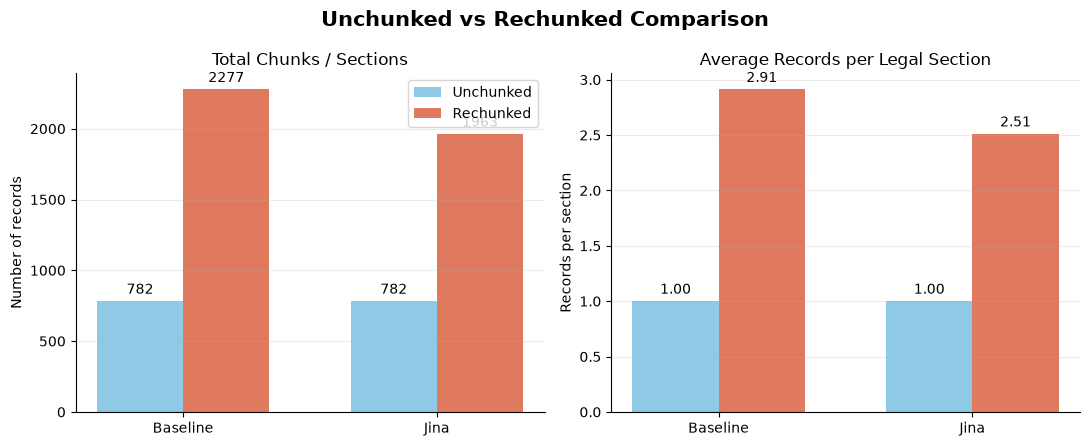

Saved comparison plot to results\plot_unchunked_vs_rechunked.png


In [10]:
import matplotlib.pyplot as plt

client = ingest.get_client()
collection_keys = {
    'Baseline': ('baseline_unchunked', 'baseline_rechunked'),
    'Jina': ('jina_unchunked', 'jina_rechunked'),
}

collection_counts = {
    key: int(client.get_collection(config.COLLECTIONS[key]).points_count or 0)
    for pair in collection_keys.values()
    for key in pair
}

models = list(collection_keys)
unchunked_counts = [collection_counts[collection_keys[model][0]] for model in models]
rechunked_counts = [collection_counts[collection_keys[model][1]] for model in models]
unchunked_average = [count / len(sections) for count in unchunked_counts]
rechunked_average = [count / len(sections) for count in rechunked_counts]

config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Unchunked vs Rechunked Comparison', fontsize=15, fontweight='bold')
bar_width = 0.34
positions = range(len(models))

bars = axes[0].bar(
    [position - bar_width / 2 for position in positions],
    unchunked_counts,
    bar_width,
    label='Unchunked',
    color='#8ecae6',
)
bars_rechunked = axes[0].bar(
    [position + bar_width / 2 for position in positions],
    rechunked_counts,
    bar_width,
    label='Rechunked',
    color='#e07a5f',
)
axes[0].set_title('Total Chunks / Sections')
axes[0].set_ylabel('Number of records')
axes[0].set_xticks(list(positions), models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)
axes[0].bar_label(bars, padding=3)
axes[0].bar_label(bars_rechunked, padding=3)

bars = axes[1].bar(
    [position - bar_width / 2 for position in positions],
    unchunked_average,
    bar_width,
    label='Unchunked',
    color='#8ecae6',
)
bars_rechunked = axes[1].bar(
    [position + bar_width / 2 for position in positions],
    rechunked_average,
    bar_width,
    label='Rechunked',
    color='#e07a5f',
)
axes[1].set_title('Average Records per Legal Section')
axes[1].set_ylabel('Records per section')
axes[1].set_xticks(list(positions), models)
axes[1].grid(axis='y', alpha=0.25)
axes[1].bar_label(bars, fmt='%.2f', padding=3)
axes[1].bar_label(bars_rechunked, fmt='%.2f', padding=3)

for axis in axes:
    axis.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plot_path = config.RESULTS_DIR / 'plot_unchunked_vs_rechunked.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved comparison plot to {plot_path.relative_to(config.ROOT_DIR)}')